In [ ]:
import os
import json
import pandas as pd


base_dir = "../Model_results"

conditions = [
    "shuffle_allframes",
    "shuffle_not_allframes",
    "not_shuffle_allframes",
    "not_shuffle_not_allframes",
]

proteins = ["3UTQ", "5C0F", "5N1Y", "pep_free"]
replicas = [0, 1, 2]
fractions = [10, 20, 30, 40, 50, 60, 70]


rows = []

for condition in conditions:
    for protein in proteins:
        for rep in replicas:
            for frac in fractions:
                stats_path = os.path.join(
                    base_dir,
                    condition,
                    protein,
                    f"{protein}_rep_{rep}",
                    f"fraction_{frac}",
                    "generation_stats.json"
                )

                if not os.path.exists(stats_path):
                    print(f"[WARNING] Missing: {stats_path}")
                    continue

                with open(stats_path, "r") as f:
                    stats = json.load(f)

                row = {
                    "condition": condition,
                    "protein": protein,
                    "replica": rep,
                    "fraction": frac,
                }

                row.update(stats)
                rows.append(row)


generation_df = pd.DataFrame(rows)

if generation_df.empty:
    raise ValueError("No generation_stats.json files were found.")

# Optional: sort nicely
generation_df = generation_df.sort_values(
    by=["condition", "protein", "replica", "fraction"]
).reset_index(drop=True)


out_dir = os.path.join(base_dir, "Analysis_results_generation_stats")
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "generation_stats_all_runs.csv")
generation_df.to_csv(csv_path, index=False)

print("[INFO] Saved combined table to:")
print(csv_path)

print("\n[INFO] Shape:")
print(generation_df.shape)

print("\n[INFO] Preview:")
print(generation_df.head())

[INFO] Saved combined table to:
../Model_results/Analysis_results_generation_stats/generation_stats_all_runs.csv

[INFO] Shape:
(336, 20)

[INFO] Preview:
               condition protein  replica  fraction  target_n_frames  \
0  not_shuffle_allframes    3UTQ        0        10             1000   
1  not_shuffle_allframes    3UTQ        0        20             1000   
2  not_shuffle_allframes    3UTQ        0        30             1000   
3  not_shuffle_allframes    3UTQ        0        40             1000   
4  not_shuffle_allframes    3UTQ        0        50             1000   

   returned_n_frames  total_attempted_frames  \
0               1000                    6208   
1               1000                    4160   
2               1000                    2752   
3               1000                    1728   
4               1000                    1344   

   total_accepted_frames_before_trim  acceptance_rate  rama_failed_total  \
0                               1001         0.

In [3]:
generation_df

,condition,protein,replica,fraction,target_n_frames,returned_n_frames,total_attempted_frames,total_accepted_frames_before_trim,acceptance_rate,rama_failed_total,bond_failed_total,both_failed_total,temperature,batch_size,max_attempts,rama_outlier_threshold,bond_bad_threshold,n_atoms,n_generation_loops,seed
0,not_shuffle_allframes,3UTQ,0,10,1000,1000,6208,1001,0.161244,4820,4858,4471,1.5,64,50000,0.1,0.15,1544,97,2052
1,not_shuffle_allframes,3UTQ,0,20,1000,1000,4160,1012,0.243269,2910,2763,2525,1.5,64,50000,0.1,0.15,1544,65,2062
2,not_shuffle_allframes,3UTQ,0,30,1000,1000,2752,1008,0.366279,1606,1446,1308,1.5,64,50000,0.1,0.15,1544,43,2072
3,not_shuffle_allframes,3UTQ,0,40,1000,1000,1728,1006,0.582176,602,570,450,1.5,64,50000,0.1,0.15,1544,27,2082
4,not_shuffle_allframes,3UTQ,0,50,1000,1000,1344,1017,0.756696,269,200,142,1.5,64,50000,0.1,0.15,1544,21,2092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,shuffle_not_allframes,pep_free,2,30,1000,1000,6400,1000,0.156250,5114,5192,4906,1.5,64,50000,0.1,0.15,1504,100,1272
332,shuffle_not_allframes,pep_free,2,40,1000,1000,5312,1006,0.189383,3947,4185,3826,1.5,64,50000,0.1,0.15,1504,83,1282
333,shuffle_not_allframes,pep_free,2,50,1000,1000,6400,1002,0.156562,5160,5210,4972,1.5,64,50000,0.1,0.15,1504,100,1292
334,shuffle_not_allframes,pep_free,2,60,1000,1000,4480,1000,0.223214,3228,3348,3096,1.5,64,50000,0.1,0.15,1504,70,1302


In [4]:
print("Shape:", generation_df.shape)
print("Expected rows:", 4 * 4 * 3 * 7)
print("Missing rows:", 4 * 4 * 3 * 7 - len(generation_df))

print("\nColumns:")
print(generation_df.columns.tolist())

Shape: (336, 20)
Expected rows: 336
Missing rows: 0

Columns:
['condition', 'protein', 'replica', 'fraction', 'target_n_frames', 'returned_n_frames', 'total_attempted_frames', 'total_accepted_frames_before_trim', 'acceptance_rate', 'rama_failed_total', 'bond_failed_total', 'both_failed_total', 'temperature', 'batch_size', 'max_attempts', 'rama_outlier_threshold', 'bond_bad_threshold', 'n_atoms', 'n_generation_loops', 'seed']


In [5]:
condition_summary = (
    generation_df.groupby("condition", as_index=False)
    .agg({
        "acceptance_rate": ["mean", "std", "min", "max"],
        "total_attempted_frames": ["mean", "std", "min", "max"],
        "rama_failed_total": ["mean", "std"],
        "bond_failed_total": ["mean", "std"],
        "both_failed_total": ["mean", "std"],
    })
)

condition_summary.columns = [
    "_".join(col).strip("_") for col in condition_summary.columns.values
]

condition_summary = condition_summary.sort_values("acceptance_rate_mean", ascending=False)
condition_summary

,condition,acceptance_rate_mean,acceptance_rate_std,acceptance_rate_min,acceptance_rate_max,total_attempted_frames_mean,total_attempted_frames_std,total_attempted_frames_min,total_attempted_frames_max,rama_failed_total_mean,rama_failed_total_std,bond_failed_total_mean,bond_failed_total_std,both_failed_total_mean,both_failed_total_std
0,not_shuffle_allframes,0.629273,0.265531,0.161244,1.000000,2040.380952,1160.255496,1024,6208,925.357143,1071.354155,847.404762,1079.249272,748.428571,986.000724
1,not_shuffle_not_allframes,0.619753,0.276414,0.037328,1.000000,2525.714286,3263.454850,1024,26816,1415.321429,3184.243555,1298.190476,3168.666640,1204.976190,3087.278491
3,shuffle_not_allframes,0.369403,0.170344,0.113564,0.797656,3429.333333,1754.406592,1280,8832,2254.011905,1707.100914,2154.714286,1709.256758,1990.892857,1656.662947
2,shuffle_allframes,0.363094,0.173761,0.072483,0.954044,3731.809524,2511.246138,1088,13824,2534.750000,2422.893744,2471.583333,2471.663691,2287.571429,2377.838384


In [6]:
fraction_summary = (
    generation_df.groupby("fraction", as_index=False)
    .agg({
        "acceptance_rate": ["mean", "std", "min", "max"],
        "total_attempted_frames": ["mean", "std", "min", "max"],
        "rama_failed_total": ["mean", "std"],
        "bond_failed_total": ["mean", "std"],
        "both_failed_total": ["mean", "std"],
    })
)

fraction_summary.columns = [
    "_".join(col).strip("_") for col in fraction_summary.columns.values
]

fraction_summary = fraction_summary.sort_values("fraction")
fraction_summary

,fraction,acceptance_rate_mean,acceptance_rate_std,acceptance_rate_min,acceptance_rate_max,total_attempted_frames_mean,total_attempted_frames_std,total_attempted_frames_min,total_attempted_frames_max,rama_failed_total_mean,rama_failed_total_std,bond_failed_total_mean,bond_failed_total_std,both_failed_total_mean,both_failed_total_std
0,10,0.399118,0.211353,0.072483,0.981445,3665.333333,2833.577314,1024,13824,2444.416667,2743.029230,2298.645833,2752.364457,2089.000000,2658.513438
1,20,0.464752,0.233243,0.149107,0.992188,2781.333333,1392.750429,1024,6720,1623.937500,1326.342506,1518.708333,1305.859169,1374.979167,1234.119214
2,30,0.456832,0.253864,0.114890,1.000000,3009.333333,1766.455729,1024,8704,1847.833333,1689.177218,1771.458333,1722.532413,1623.500000,1640.912149
3,40,0.501705,0.261127,0.037328,1.000000,3164.000000,3879.735547,1024,26816,2019.625000,3801.076296,1944.979167,3812.100976,1816.104167,3729.338908
4,50,0.555030,0.275742,0.080702,1.000000,2604.000000,2059.844737,1024,12416,1473.354167,1970.368326,1413.416667,2013.018342,1300.750000,1916.860004
5,60,0.557674,0.279064,0.113564,1.000000,2608.000000,1919.387136,1024,8832,1496.020833,1865.881225,1410.020833,1845.122397,1315.354167,1785.079657
6,70,0.532556,0.276987,0.081543,1.000000,2690.666667,2019.847280,1024,12288,1571.333333,1923.034828,1493.583333,1959.835108,1386.083333,1859.040027


In [7]:
protein_summary = (
    generation_df.groupby("protein", as_index=False)
    .agg({
        "acceptance_rate": ["mean", "std", "min", "max"],
        "total_attempted_frames": ["mean", "std", "min", "max"],
        "rama_failed_total": ["mean", "std"],
        "bond_failed_total": ["mean", "std"],
        "both_failed_total": ["mean", "std"],
    })
)

protein_summary.columns = [
    "_".join(col).strip("_") for col in protein_summary.columns.values
]

protein_summary = protein_summary.sort_values("acceptance_rate_mean", ascending=False)
protein_summary

,protein,acceptance_rate_mean,acceptance_rate_std,acceptance_rate_min,acceptance_rate_max,total_attempted_frames_mean,total_attempted_frames_std,total_attempted_frames_min,total_attempted_frames_max,rama_failed_total_mean,rama_failed_total_std,bond_failed_total_mean,bond_failed_total_std,both_failed_total_mean,both_failed_total_std
3,pep_free,0.667385,0.319785,0.128586,1.000000,2233.142857,1713.647284,1024,7808,1132.476190,1639.869672,1111.857143,1646.863014,1028.666667,1567.124966
2,5N1Y,0.460308,0.179953,0.113564,0.888889,2610.285714,1245.137633,1152,8832,1477.464286,1209.621592,1327.785714,1204.872088,1207.952381,1166.205606
0,3UTQ,0.431121,0.194242,0.072483,0.914062,3052.190476,1988.856270,1152,13824,1879.059524,1925.725839,1786.059524,1916.499069,1627.059524,1849.671956
1,5C0F,0.422710,0.246182,0.037328,0.954044,3831.619048,3657.150625,1088,26816,2640.440476,3551.418275,2546.190476,3589.909981,2368.190476,3479.364730


In [8]:
replica_summary = (
    generation_df.groupby(["protein", "replica"], as_index=False)
    .agg({
        "acceptance_rate": ["mean", "std"],
        "total_attempted_frames": ["mean", "std"],
    })
)

replica_summary.columns = [
    "_".join(col).strip("_") for col in replica_summary.columns.values
]

replica_summary = replica_summary.sort_values(["protein", "replica"])
replica_summary

,protein,replica,acceptance_rate_mean,acceptance_rate_std,total_attempted_frames_mean,total_attempted_frames_std
0,3UTQ,0,0.475721,0.220730,2950.857143,2489.843989
1,3UTQ,1,0.385058,0.175982,3298.285714,1700.119187
2,3UTQ,2,0.432584,0.178962,2907.428571,1724.742373
3,5C0F,0,0.509714,0.260858,2939.428571,2485.306083
4,5C0F,1,0.505671,0.215850,2653.714286,1912.120693
5,5C0F,2,0.252746,0.163474,5901.714286,4957.184796
6,5N1Y,0,0.430702,0.177421,2905.142857,1642.651824
7,5N1Y,1,0.413498,0.134632,2722.285714,908.189198
8,5N1Y,2,0.536722,0.201760,2203.428571,983.869738
9,pep_free,0,0.711936,0.297547,1844.571429,1187.924285


In [9]:
condition_fraction_pivot = generation_df.pivot_table(
    index="condition",
    columns="fraction",
    values="acceptance_rate",
    aggfunc="mean"
)

condition_fraction_pivot

fraction,10,20,30,40,50,60,70
condition,,,,,,,
not_shuffle_allframes,0.438060,0.520452,0.600561,0.644811,0.711617,0.734541,0.754868
not_shuffle_not_allframes,0.432823,0.519485,0.583238,0.632978,0.749268,0.734602,0.685878
shuffle_allframes,0.350229,0.405584,0.316192,0.366895,0.359600,0.420916,0.322244
shuffle_not_allframes,0.375360,0.413489,0.327338,0.362135,0.399633,0.340636,0.367233


In [10]:
protein_condition_pivot = generation_df.pivot_table(
    index="protein",
    columns="condition",
    values="acceptance_rate",
    aggfunc="mean"
)

protein_condition_pivot

condition,not_shuffle_allframes,not_shuffle_not_allframes,shuffle_allframes,shuffle_not_allframes
protein,,,,
3UTQ,0.501569,0.506395,0.387026,0.329494
5C0F,0.535847,0.457812,0.338838,0.358345
5N1Y,0.522232,0.563128,0.329688,0.426182
pep_free,0.957444,0.951678,0.396825,0.363593


In [12]:
condition_report = condition_summary[[
    "condition",
    "acceptance_rate_mean",
    "acceptance_rate_std",
    "total_attempted_frames_mean",
    "total_attempted_frames_std",
    "rama_failed_total_mean",
    "bond_failed_total_mean",
    "both_failed_total_mean"
]].copy()

condition_report = condition_report.sort_values("acceptance_rate_mean", ascending=False)
condition_report

,condition,acceptance_rate_mean,acceptance_rate_std,total_attempted_frames_mean,total_attempted_frames_std,rama_failed_total_mean,bond_failed_total_mean,both_failed_total_mean
0,not_shuffle_allframes,0.629273,0.265531,2040.380952,1160.255496,925.357143,847.404762,748.428571
1,not_shuffle_not_allframes,0.619753,0.276414,2525.714286,3263.454850,1415.321429,1298.190476,1204.976190
3,shuffle_not_allframes,0.369403,0.170344,3429.333333,1754.406592,2254.011905,2154.714286,1990.892857
2,shuffle_allframes,0.363094,0.173761,3731.809524,2511.246138,2534.750000,2471.583333,2287.571429


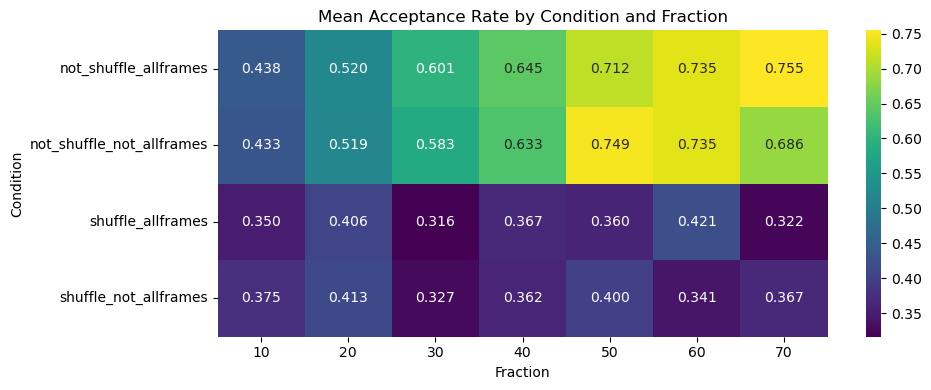

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.heatmap(condition_fraction_pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Mean Acceptance Rate by Condition and Fraction")
plt.xlabel("Fraction")
plt.ylabel("Condition")
plt.tight_layout()
plt.show()